In [5]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_ROOT = Path("/project/def-nahee/kbas/Graphnet-Applications/Results/340StringMC")
DEFAULT_EXPERIMENT = "baseline"
DEFAULT_FLAVORS = ["Muon", "Electron", "Tau", "NC"]
EVENT_WEIGHT_DIR = Path("/project/def-nahee/kbas/Graphnet-Applications/Metadata/DatasetStatistics/TruthLevelStatistics")
EVENT_KEY_COLUMNS = ["RunID", "SubrunID", "EventID", "SubEventID"]
WEIGHT_FILES = {
    "Muon": "Muon.csv",
    "Electron": "Electron.csv",
    "Tau": "Tau.csv",
    "NC": "NC.csv",
}

CATEGORY_LABELS = {
    "category1_isMuonCC": "Muon CC routing",
    "category2_tauCC_others_muonCC": "Tau CC / other / Muon CC routing",
    "category_3_contains_muon": "Contains-muon routing",
}


def _prediction_path(geometry, category, experiment_name=DEFAULT_EXPERIMENT):
    return (
        RESULTS_ROOT
        / geometry
        / "inference"
        / category
        / experiment_name
        / "inference"
        / "inference_predictions.csv"
    )


def _opening_angle_deg(theta_true, phi_true, theta_pred, phi_pred):
    cos_delta = (
        np.sin(theta_true) * np.sin(theta_pred) * np.cos(phi_true - phi_pred)
        + np.cos(theta_true) * np.cos(theta_pred)
    )
    return np.degrees(np.arccos(np.clip(cos_delta, -1.0, 1.0)))


def _weighted_quantile(values, quantiles, weights=None):
    values = np.asarray(values, dtype=float)
    quantiles = np.asarray(quantiles, dtype=float)
    if weights is None:
        return np.quantile(values[np.isfinite(values)], quantiles)

    weights = np.asarray(weights, dtype=float)
    valid = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    values = values[valid]
    weights = weights[valid]
    if values.size == 0:
        return np.full(quantiles.shape, np.nan)
    order = np.argsort(values)
    values = values[order]
    weights = weights[order]
    cumulative = np.cumsum(weights) - 0.5 * weights
    cumulative /= weights.sum()
    return np.interp(quantiles, cumulative, values)


def _load_event_weights():
    pieces = []
    for flavor, filename in WEIGHT_FILES.items():
        path = EVENT_WEIGHT_DIR / filename
        if not path.is_file():
            raise FileNotFoundError(f"Event-weight file not found: {path}")
        weights = pd.read_csv(
            path,
            usecols=[*EVENT_KEY_COLUMNS, "final_weight"],
        )
        if weights.duplicated(EVENT_KEY_COLUMNS).any():
            raise ValueError(f"Duplicate event keys in event-weight file: {path}")
        weights["flavor"] = flavor
        weights = weights.rename(columns={"final_weight": "event_weight"})
        pieces.append(weights[[*EVENT_KEY_COLUMNS, "flavor", "event_weight"]])
    return pd.concat(pieces, ignore_index=True)


def _add_flavor(frame):
    frame = frame.copy()
    pid_flavor = frame["pid"].abs().astype("Int64").map(
        {12: "Electron", 14: "Muon", 16: "Tau"}
    )
    frame["flavor"] = np.where(
        frame["is_CC"].astype("Int64") == 0,
        "NC",
        pid_flavor,
    )
    return frame.dropna(subset=["flavor"])


def _prepare_predictions(geometry, category, experiment_name):
    path = _prediction_path(geometry, category, experiment_name)
    if not path.is_file():
        raise FileNotFoundError(f"Inference predictions not found: {path}")

    frame = pd.read_csv(path)
    required = {
        "event_key", "pid", "is_CC", "true_energy", "pred_energy",
        "true_zenith_radian", "pred_zenith_radian",
        "true_azimuth_radian", "pred_azimuth_radian",
    }
    missing = sorted(required.difference(frame.columns))
    if missing:
        raise KeyError(f"{category} is missing required columns: {missing}")
    if not frame["event_key"].is_unique:
        raise ValueError(f"{category} contains duplicate event_key values")

    frame = _add_flavor(frame)
    frame["true_log10_energy"] = np.log10(frame["true_energy"])
    frame["energy_log10_residual"] = np.log10(frame["pred_energy"] / frame["true_energy"])
    frame["opening_angle_degree"] = _opening_angle_deg(
        frame["true_zenith_radian"],
        frame["true_azimuth_radian"],
        frame["pred_zenith_radian"],
        frame["pred_azimuth_radian"],
    )
    return frame


def _binned_summary(frame, energy_edges, use_event_weight):
    required = ["true_log10_energy", "opening_angle_degree", "energy_log10_residual"]
    if use_event_weight:
        required.append("event_weight")
    work = frame.replace([np.inf, -np.inf], np.nan).dropna(subset=required).copy()
    work["energy_bin"] = pd.cut(
        work["true_log10_energy"], bins=energy_edges, include_lowest=True
    )

    rows = []
    for _, group in work.groupby("energy_bin", observed=True):
        weights = group["event_weight"] if use_event_weight else None
        opening_p16, opening_median, opening_p84 = _weighted_quantile(
            group["opening_angle_degree"], [0.16, 0.50, 0.84], weights
        )
        energy_p16, energy_p84 = _weighted_quantile(
            group["energy_log10_residual"], [0.16, 0.84], weights
        )
        rows.append(
            {
                "bin_center_log10": np.average(
                    group["true_log10_energy"], weights=weights
                ),
                "count": len(group),
                "sum_event_weight": weights.sum() if use_event_weight else np.nan,
                "opening_median": opening_median,
                "opening_p16": opening_p16,
                "opening_p84": opening_p84,
                "energy_resolution": 0.5 * (energy_p84 - energy_p16),
            }
        )
    summary = pd.DataFrame(rows)
    summary["bin_center_energy"] = 10 ** summary["bin_center_log10"]
    return summary


def compare_classification_approaches(
    geometry,
    categories,
    experiment_name=DEFAULT_EXPERIMENT,
    n_energy_bins=10,
    category_labels=None,
    use_event_weight=False,
):
    """Compare routed reconstruction performance for two or more classifiers."""
    categories = list(dict.fromkeys(categories))
    if len(categories) < 2:
        raise ValueError("Provide at least two distinct category names")

    frames = {
        category: _prepare_predictions(geometry, category, experiment_name)
        for category in categories
    }

    if use_event_weight:
        event_weights = _load_event_weights()
        for category, frame in frames.items():
            merged = frame.merge(
                event_weights,
                on=[*EVENT_KEY_COLUMNS, "flavor"],
                how="left",
                validate="one_to_one",
            )
            missing_weights = int(merged["event_weight"].isna().sum())
            if missing_weights:
                raise ValueError(
                    f"{category}: {missing_weights:,} inference events have no event weight"
                )
            frames[category] = merged

    reference_category = categories[0]
    reference_keys = set(frames[reference_category]["event_key"])
    for category in categories[1:]:
        keys = set(frames[category]["event_key"])
        if keys != reference_keys:
            raise ValueError(
                f"Event sets differ between {reference_category} and {category}: "
                f"reference={len(reference_keys):,}, current={len(keys):,}, "
                f"missing={len(reference_keys - keys):,}, extra={len(keys - reference_keys):,}"
            )

    all_log_energy = pd.concat(
        [frame["true_log10_energy"] for frame in frames.values()], ignore_index=True
    ).replace([np.inf, -np.inf], np.nan).dropna()
    energy_edges = np.linspace(all_log_energy.min(), all_log_energy.max(), n_energy_bins + 1)

    labels = dict(CATEGORY_LABELS)
    if category_labels:
        labels.update(category_labels)
    colors = plt.cm.tab10(np.linspace(0, 1, len(categories)))

    fig, axes = plt.subplots(2, 4, figsize=(22, 10), sharex="col")
    summaries = []

    for col, flavor in enumerate(DEFAULT_FLAVORS):
        for color, category in zip(colors, categories):
            flavor_frame = frames[category][frames[category]["flavor"] == flavor]
            summary = _binned_summary(flavor_frame, energy_edges, use_event_weight)
            summary["geometry"] = geometry
            summary["category"] = category
            summary["flavor"] = flavor
            summaries.append(summary)

            label = labels.get(category, category)
            axes[0, col].plot(
                summary["bin_center_energy"],
                summary["opening_median"],
                marker="o", linewidth=2, color=color, label=label,
            )
            axes[0, col].fill_between(
                summary["bin_center_energy"],
                summary["opening_p16"],
                summary["opening_p84"],
                color=color, alpha=0.10, linewidth=0,
            )
            axes[1, col].plot(
                summary["bin_center_energy"],
                summary["energy_resolution"],
                marker="o", linewidth=2, color=color, label=label,
            )

        axes[0, col].set_title(flavor)
        axes[0, col].set_xscale("log")
        axes[1, col].set_xscale("log")
        axes[0, col].grid(True, alpha=0.25, which="both")
        axes[1, col].grid(True, alpha=0.25, which="both")
        axes[1, col].set_xlabel(r"True energy $E$ [GeV]")

    axes[0, 0].set_ylabel(r"Median opening angle $\Psi$ [deg]")
    axes[1, 0].set_ylabel(r"Energy resolution: $\frac{P_{84}-P_{16}}{2}$ of $\log_{10}(E_\mathrm{pred}/E_\mathrm{true})$")
    axes[0, -1].legend(loc="best", fontsize=9)
    axes[1, -1].legend(loc="best", fontsize=9)
    weight_label = "event-weighted" if use_event_weight else "unweighted"
    fig.suptitle(
        f"Classification-routing comparison: {geometry} ({weight_label})", fontsize=16
    )
    fig.tight_layout()
    plt.show()

    return pd.concat(summaries, ignore_index=True)




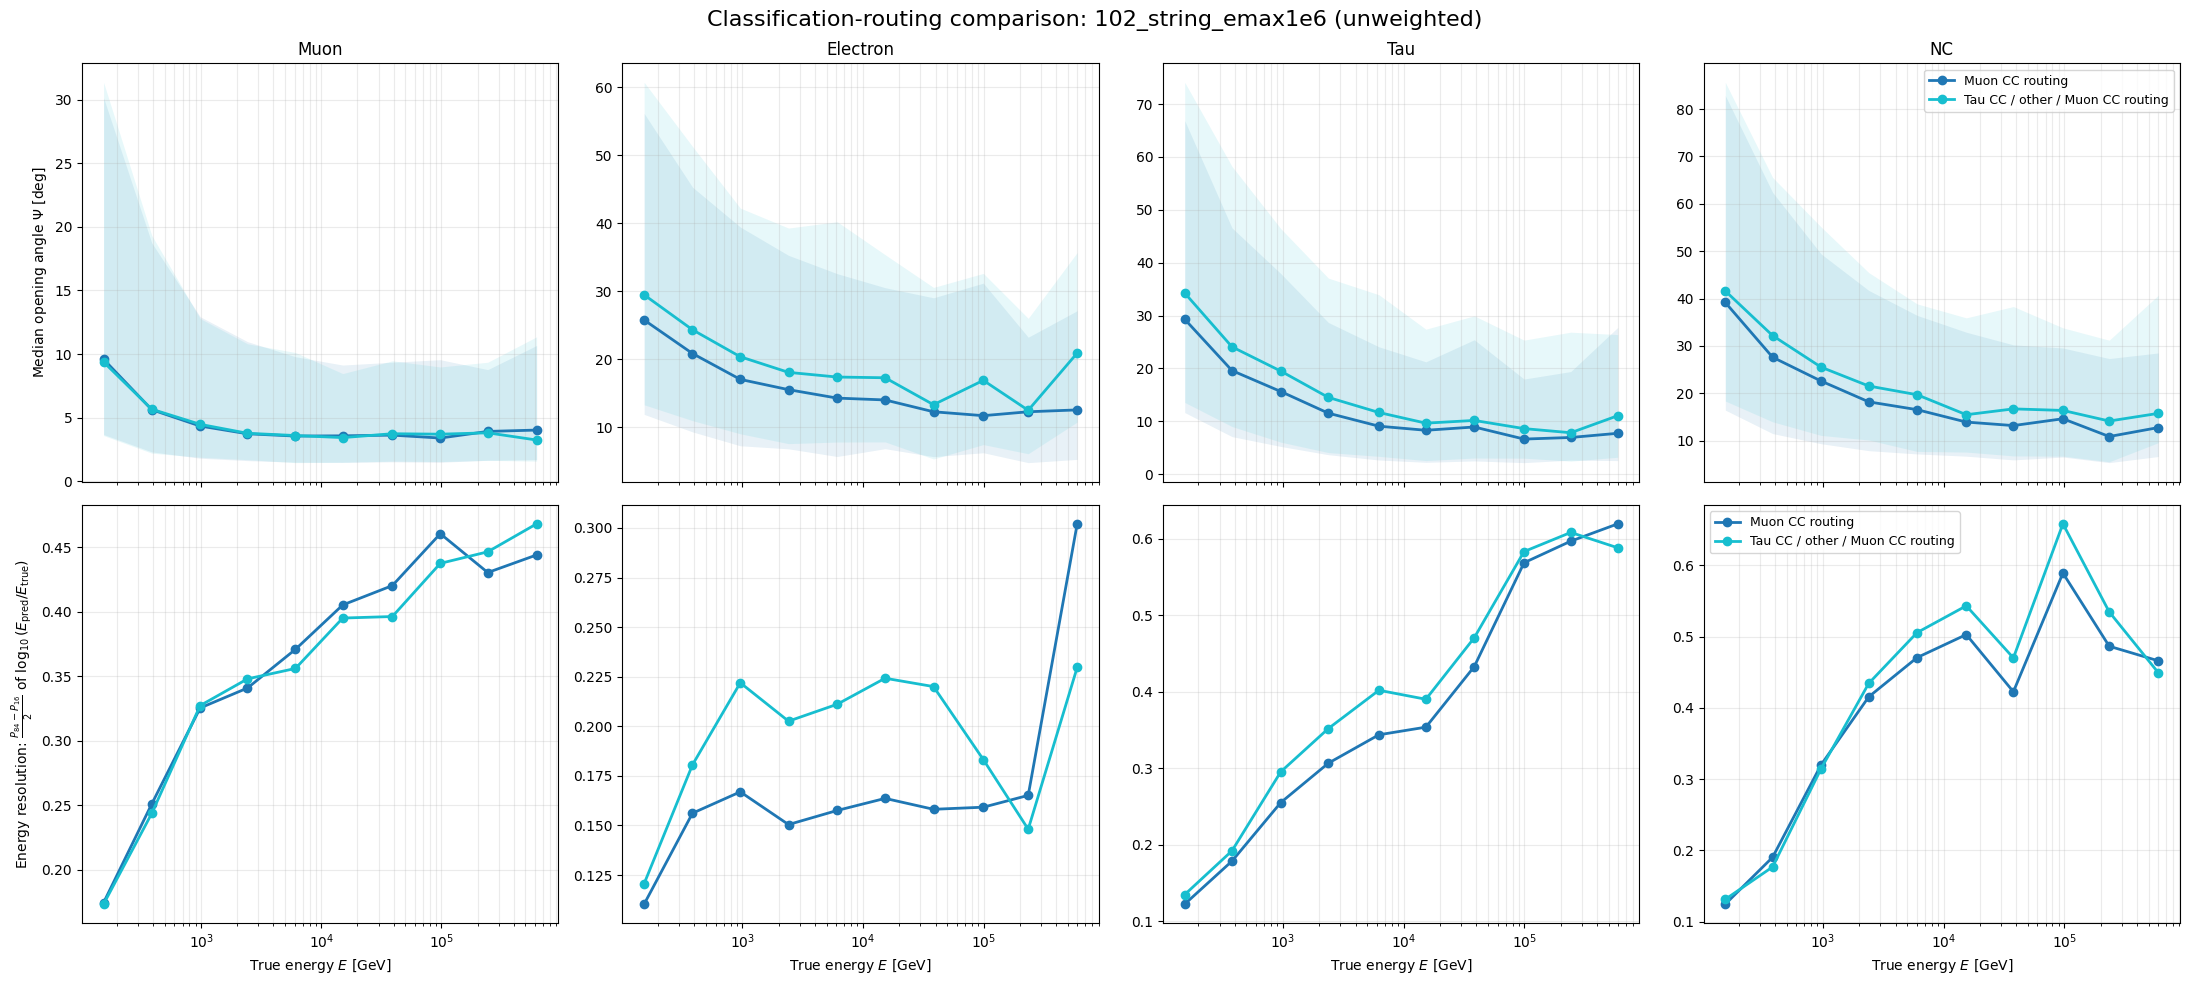

,bin_center_log10,count,sum_event_weight,opening_median,opening_p16,opening_p84,energy_resolution,bin_center_energy,geometry,category,flavor
0,2.188205,5428,NaN,9.588418,3.674016,30.144439,0.174530,154.242675,102_string_emax1e6,category1_isMuonCC,Muon
1,2.589002,4132,NaN,5.626789,2.309338,18.733661,0.251043,388.152549,102_string_emax1e6,category1_isMuonCC,Muon
2,2.992026,3345,NaN,4.339730,1.811576,12.933007,0.325449,981.806900,102_string_emax1e6,category1_isMuonCC,Muon
3,3.385779,2639,NaN,3.732220,1.622641,10.974612,0.340885,2430.964399,102_string_emax1e6,category1_isMuonCC,Muon
4,3.785181,1815,NaN,3.552399,1.498317,9.787177,0.370890,6097.912048,102_string_emax1e6,category1_isMuonCC,Muon


In [6]:

comparison_summary = compare_classification_approaches(
    geometry="102_string_emax1e6",
    categories=[
        "category1_isMuonCC",
        "category2_tauCC_others_muonCC",
    ],
    use_event_weight=False,
)
comparison_summary.head()

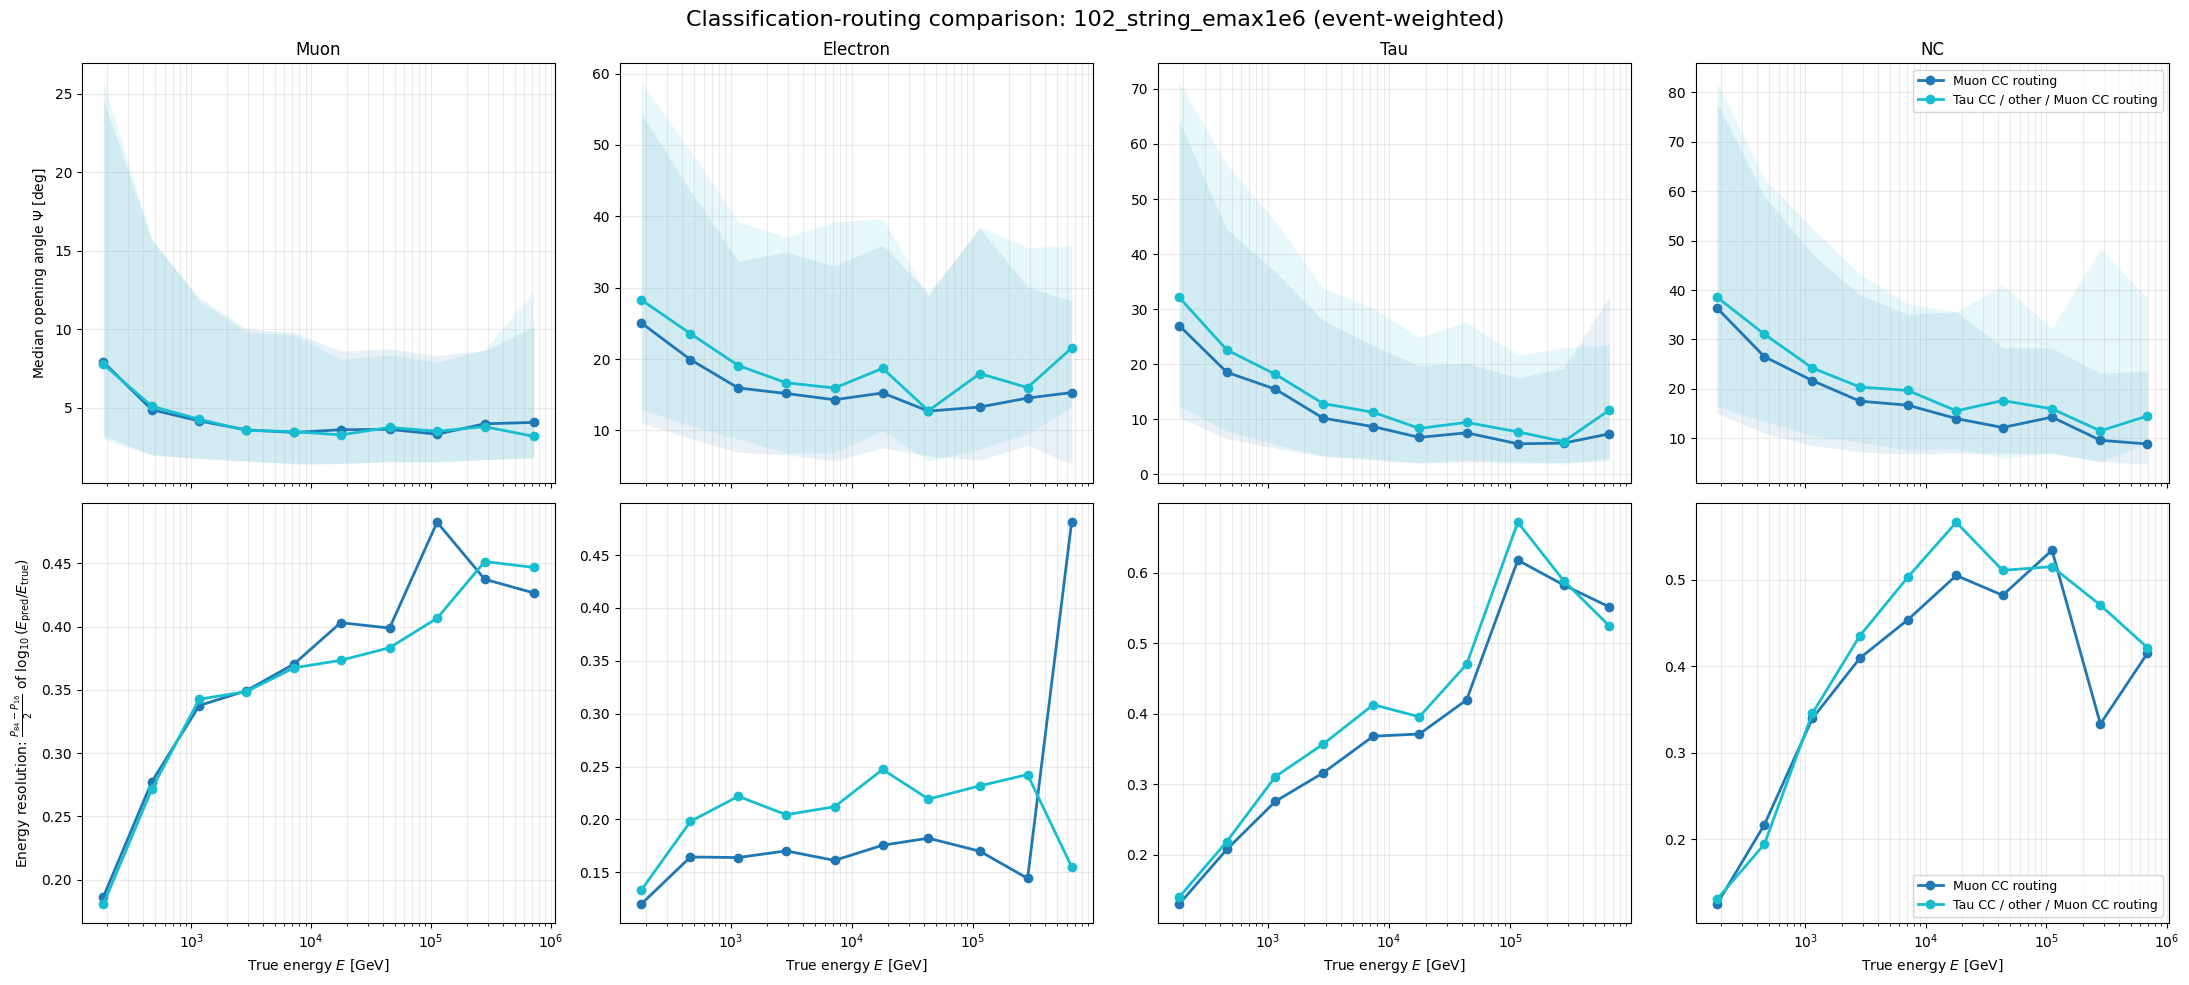

,bin_center_log10,count,sum_event_weight,opening_median,opening_p16,opening_p84,energy_resolution,bin_center_energy,geometry,category,flavor
0,2.268192,5428,2.067319e+05,7.914281,3.214418,24.596717,0.186541,185.435008,102_string_emax1e6,category1_isMuonCC,Muon
1,2.672199,4132,2.118176e+06,4.884765,2.033961,15.663100,0.277447,470.109544,102_string_emax1e6,category1_isMuonCC,Muon
2,3.068102,3345,2.192809e+07,4.174440,1.771961,12.016881,0.337595,1169.773028,102_string_emax1e6,category1_isMuonCC,Muon
3,3.460843,2639,1.990716e+08,3.607445,1.590371,10.034992,0.349336,2889.633252,102_string_emax1e6,category1_isMuonCC,Muon
4,3.858937,1815,1.447266e+09,3.442432,1.488623,9.788759,0.370440,7226.653682,102_string_emax1e6,category1_isMuonCC,Muon


In [7]:

comparison_summary = compare_classification_approaches(
    geometry="102_string_emax1e6",
    categories=[
        "category1_isMuonCC",
        "category2_tauCC_others_muonCC",
    ],
    use_event_weight=True,
)
comparison_summary.head()

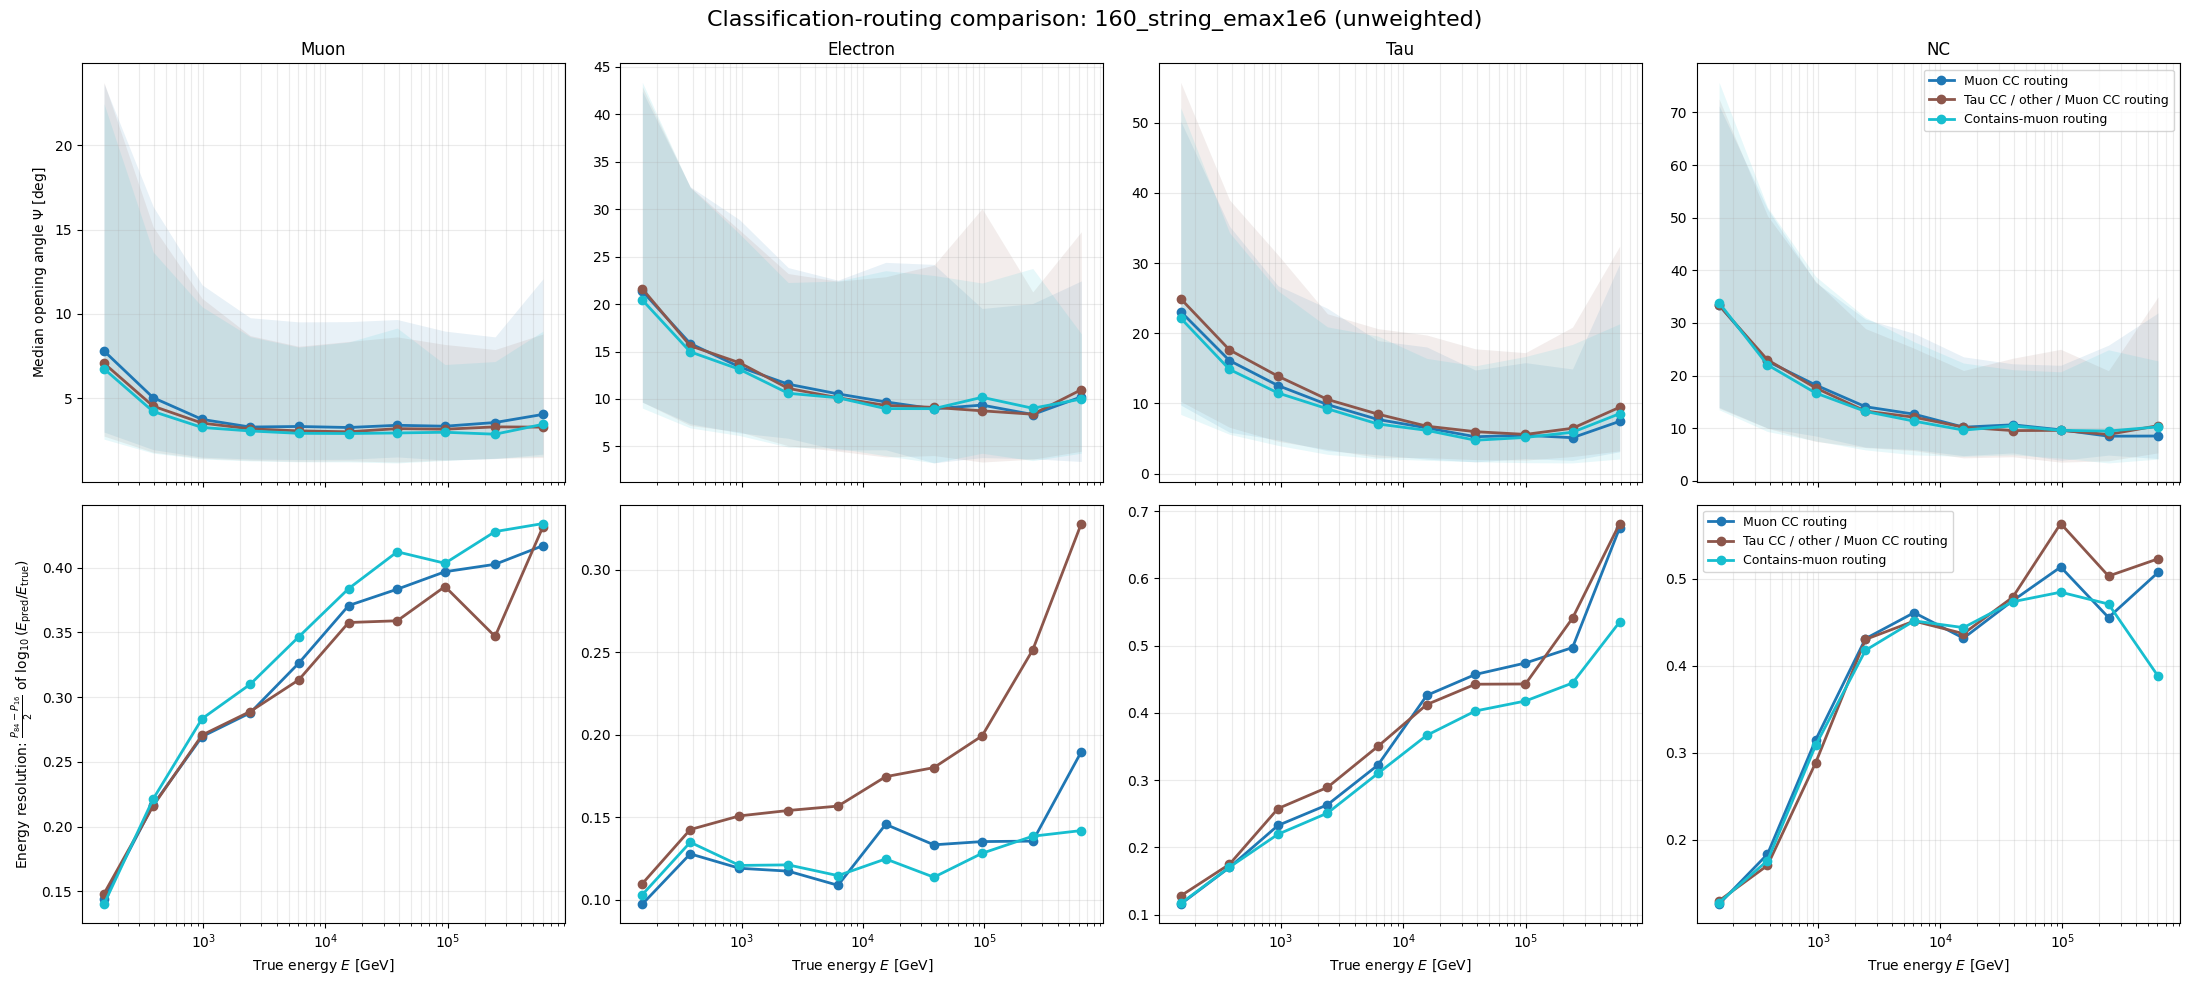

,bin_center_log10,count,sum_event_weight,opening_median,opening_p16,opening_p84,energy_resolution,bin_center_energy,geometry,category,flavor
0,2.189268,7140,NaN,7.798605,2.984706,23.670112,0.144290,154.620665,160_string_emax1e6,category1_isMuonCC,Muon
1,2.591043,4981,NaN,5.024530,1.942703,16.375958,0.216901,389.980431,160_string_emax1e6,category1_isMuonCC,Muon
2,2.991563,3804,NaN,3.735450,1.491665,11.722328,0.269588,980.761255,160_string_emax1e6,category1_isMuonCC,Muon
3,3.384383,2965,NaN,3.281447,1.384448,9.772040,0.287838,2423.164105,160_string_emax1e6,category1_isMuonCC,Muon
4,3.781958,2219,NaN,3.314493,1.350803,9.524671,0.326266,6052.827368,160_string_emax1e6,category1_isMuonCC,Muon


In [8]:

comparison_summary = compare_classification_approaches(
    geometry="160_string_emax1e6",
    categories=[
        "category1_isMuonCC",
        "category2_tauCC_others_muonCC",
        "category_3_contains_muon",
    ],
    use_event_weight=False,
)
comparison_summary.head()

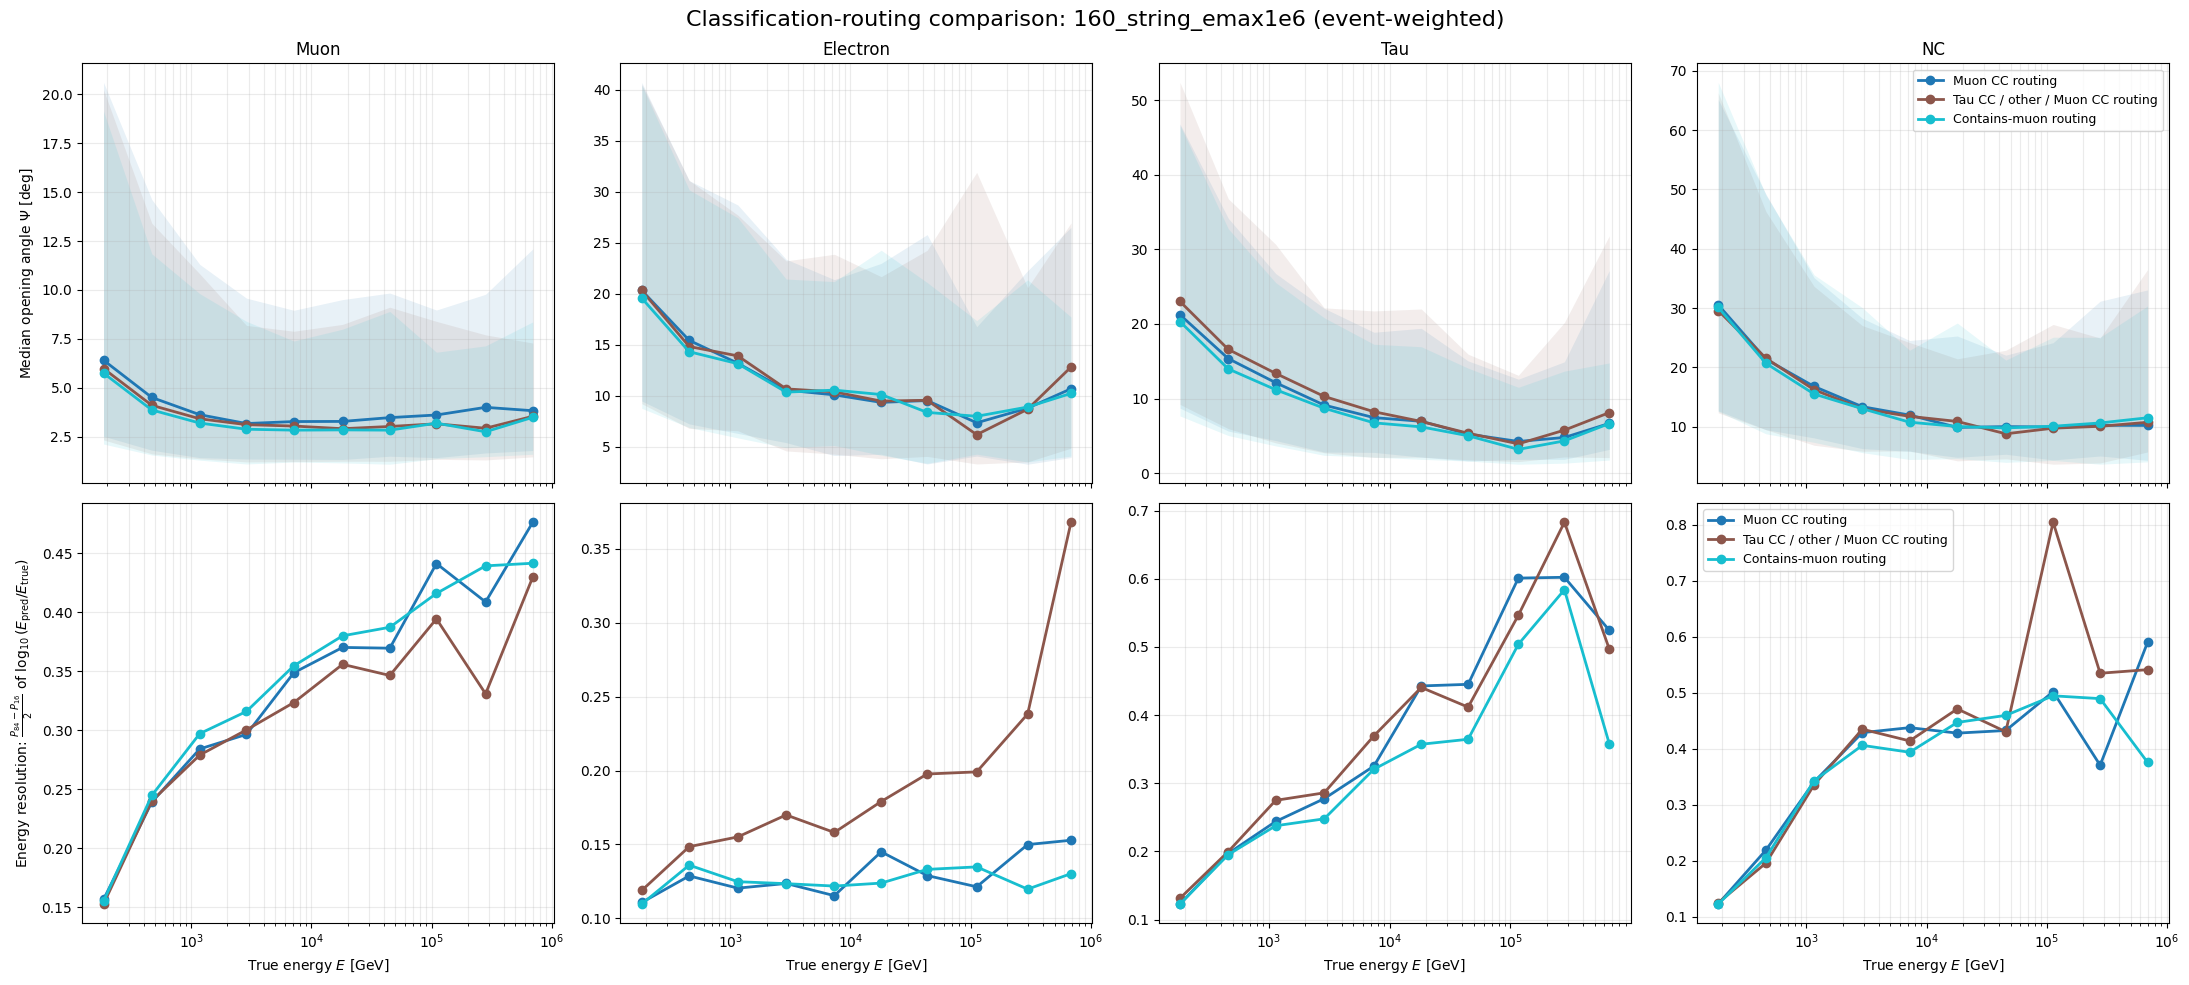

,bin_center_log10,count,sum_event_weight,opening_median,opening_p16,opening_p84,energy_resolution,bin_center_energy,geometry,category,flavor
0,2.268670,7140,2.747266e+05,6.413932,2.531627,20.598693,0.156490,185.639346,160_string_emax1e6,category1_isMuonCC,Muon
1,2.670679,4981,2.561318e+06,4.511981,1.819146,14.618962,0.239004,468.467219,160_string_emax1e6,category1_isMuonCC,Muon
2,3.070020,3804,2.498146e+07,3.631724,1.439804,11.306100,0.284052,1174.951968,160_string_emax1e6,category1_isMuonCC,Muon
3,3.458787,2965,2.180398e+08,3.179910,1.369006,9.582063,0.296381,2875.990235,160_string_emax1e6,category1_isMuonCC,Muon
4,3.853375,2219,1.713580e+09,3.281322,1.360291,8.962560,0.348633,7134.695574,160_string_emax1e6,category1_isMuonCC,Muon


In [9]:

comparison_summary = compare_classification_approaches(
    geometry="160_string_emax1e6",
    categories=[
        "category1_isMuonCC",
        "category2_tauCC_others_muonCC",
        "category_3_contains_muon",
    ],
    use_event_weight=True,
)
comparison_summary.head()